# Combined Machine Learning Workflow

Merged in workflow order from the eight supplied notebooks. Original cells and saved outputs are preserved.

# 1. Data Understanding

_Source notebook: `data_understanding.ipynb`_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dataset = pd.read_csv("malaysia_house_price_data_2025.csv")

In [12]:
dataset.head()

,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,Terrace House,331800.0,304.0,593
1,BANDAR PUTRA,Kulai,Johor,Freehold,"Cluster House, Terrace House",590900.0,322.0,519
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,Terrace House,229954.0,130.0,414
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,Terrace House,255600.0,218.0,391
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,Terrace House,219300.0,168.0,363


In [4]:
print("Dataset shape:", dataset.shape)

print("\nData types:")
print(dataset.dtypes)

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nDuplicate rows:")
print(dataset.duplicated().sum())

Dataset shape: (2000, 8)

Data types:
Township         object
Area             object
State            object
Tenure           object
Type             object
Median_Price    float64
Median_PSF      float64
Transactions      int64
dtype: object

Missing values:
Township        0
Area            0
State           0
Tenure          0
Type            0
Median_Price    0
Median_PSF      0
Transactions    0
dtype: int64

Duplicate rows:
0


RM1 million or below: 1876
Above RM1 million: 124


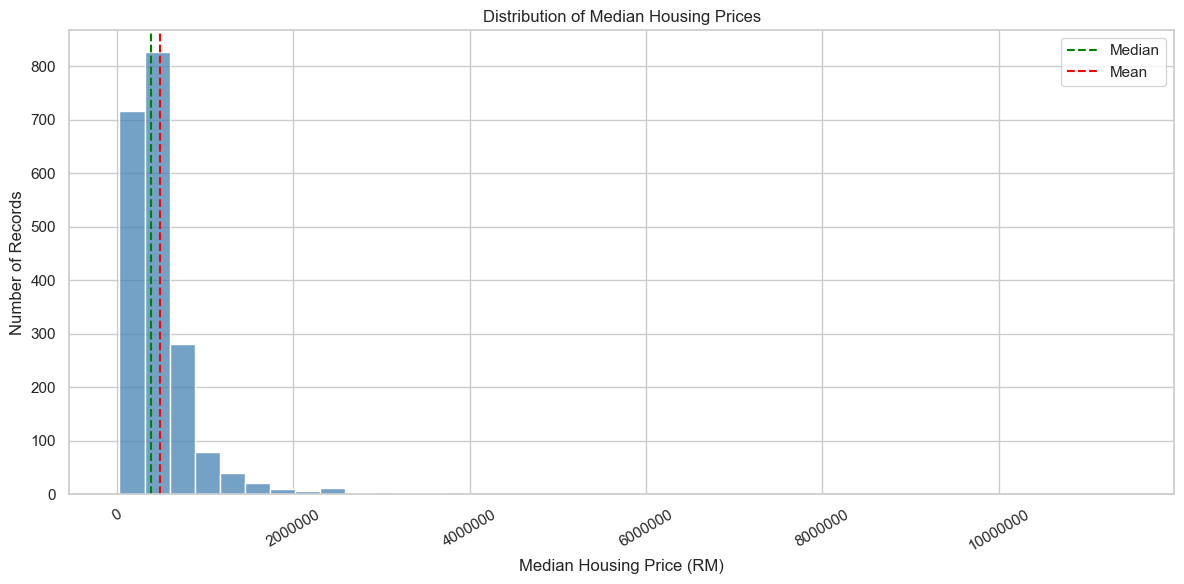

In [5]:
below_one_million = (
    dataset["Median_Price"] <= 1_000_000
).sum()

above_one_million = (
    dataset["Median_Price"] > 1_000_000
).sum()

print("RM1 million or below:", below_one_million)
print("Above RM1 million:", above_one_million)

plt.figure(figsize=(12, 6))

sns.histplot(
    dataset["Median_Price"],
    bins=40,
    color="steelblue"
)

plt.axvline(
    dataset["Median_Price"].median(),
    color="green",
    linestyle="--",
    label="Median"
)

plt.axvline(
    dataset["Median_Price"].mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

plt.title("Distribution of Median Housing Prices")
plt.xlabel("Median Housing Price (RM)")
plt.ylabel("Number of Records")

plt.ticklabel_format(style="plain", axis="x")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

plt.show()

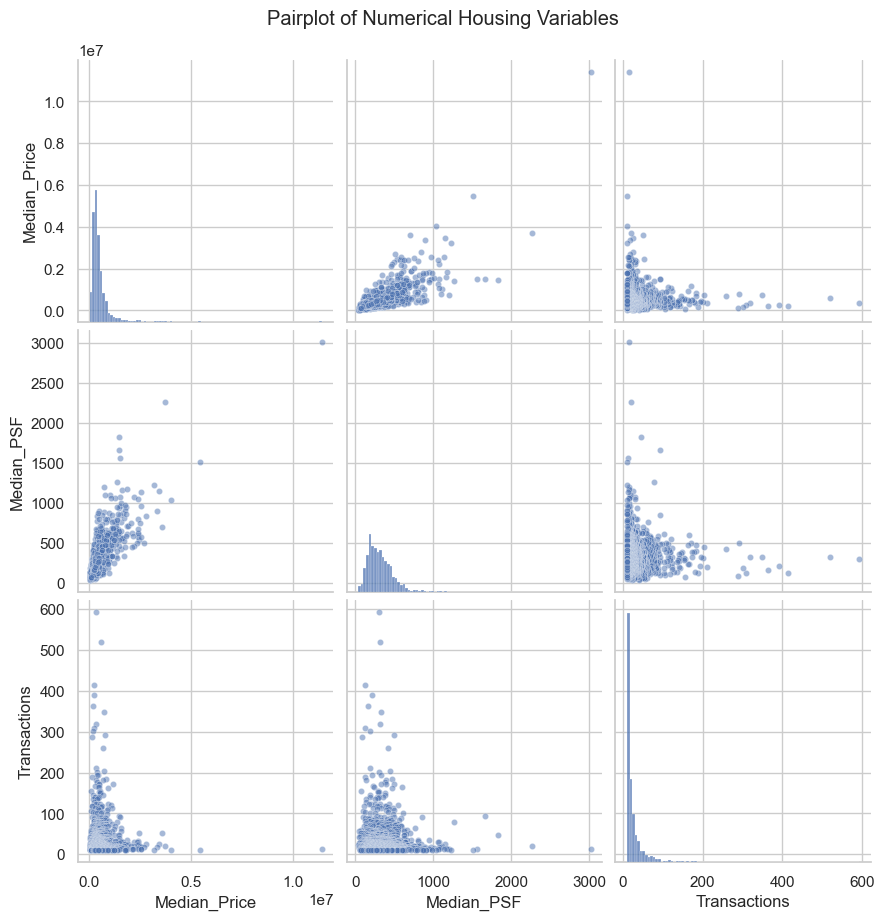

In [6]:
numerical_data = dataset[
    [
        "Median_Price",
        "Median_PSF",
        "Transactions"
    ]
]

pairplot = sns.pairplot(
    numerical_data,
    diag_kind="hist",
    height=3,
    plot_kws={
        "alpha": 0.5,
        "s": 20
    }
)

pairplot.fig.suptitle(
    "Pairplot of Numerical Housing Variables",
    y=1.02
)

plt.show()

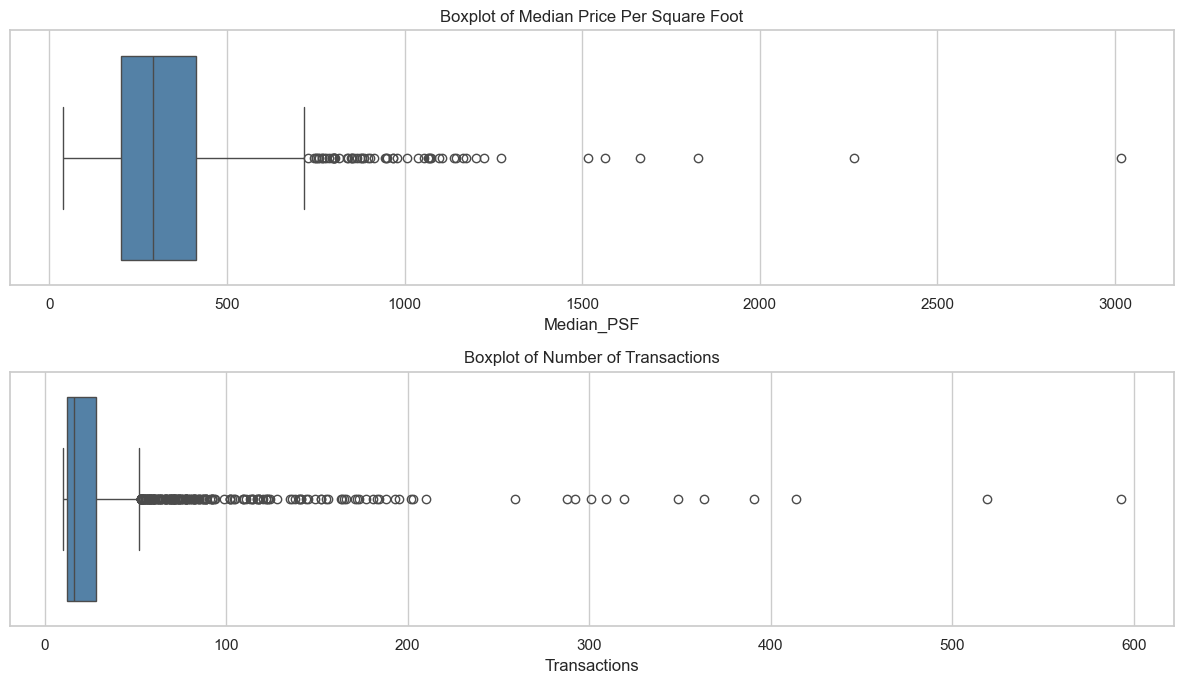

In [7]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7)
)

sns.boxplot(
    x=dataset["Median_PSF"],
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title(
    "Boxplot of Median Price Per Square Foot"
)

axes[0].set_xlabel("Median_PSF")

sns.boxplot(
    x=dataset["Transactions"],
    ax=axes[1],
    color="steelblue"
)

axes[1].set_title(
    "Boxplot of Number of Transactions"
)

axes[1].set_xlabel("Transactions")

plt.tight_layout()
plt.show()

In [8]:
features = [
    "Median_PSF",
    "Transactions"
]

for column in features:

    q1 = dataset[column].quantile(0.25)
    q3 = dataset[column].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = dataset[
        (dataset[column] < lower_limit) |
        (dataset[column] > upper_limit)
    ]

    print(
        column,
        "- Number of outliers:",
        len(outliers)
    )

Median_PSF - Number of outliers: 60
Transactions - Number of outliers: 210


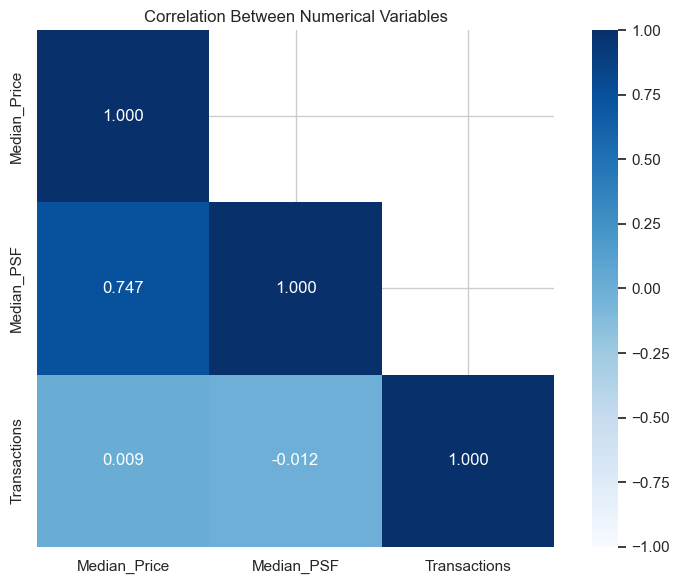

In [9]:
correlation = dataset[
    [
        "Median_Price",
        "Median_PSF",
        "Transactions"
    ]
].corr()

mask = np.triu(
    np.ones_like(
        correlation,
        dtype=bool
    ),
    k=1
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Correlation Between Numerical Variables"
)

plt.tight_layout()
plt.show()

In [10]:
dataset[
    [
        "Median_Price",
        "Median_PSF",
        "Transactions"
    ]
].describe().round(2)

,Median_Price,Median_PSF,Transactions
count,2000.00,2000.00,2000.00
mean,490685.41,328.86,28.09
std,468632.21,193.28,37.70
min,27049.00,38.00,10.00
25%,269950.00,201.00,12.00
50%,390000.00,293.00,16.00
75%,573500.00,412.00,28.00
max,11420500.00,3017.00,593.00


# 2. Data Preparation

_Source notebook: `Data Preparation.ipynb`_

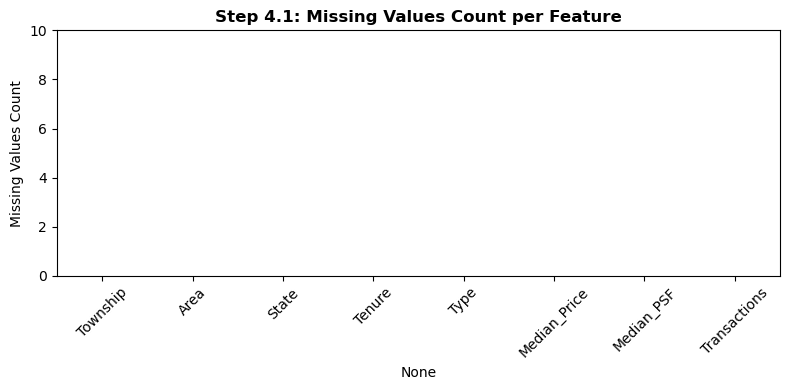

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("malaysia_house_price_data_2025.csv")

# Plot missing values count without warnings
plt.figure(figsize=(8, 4))
missing_vals = df.isnull().sum()

sns.barplot(
    x=missing_vals.index, 
    y=missing_vals.values, 
    hue=missing_vals.index, 
    palette="Blues_d"
)
plt.legend([], [], frameon=False)  # Suppresses duplicate legend

plt.title("Step 4.1: Missing Values Count per Feature", fontweight='bold')
plt.ylabel("Missing Values Count")
plt.xticks(rotation=45)
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig("step1_data_quality.png", dpi=300)
plt.show()

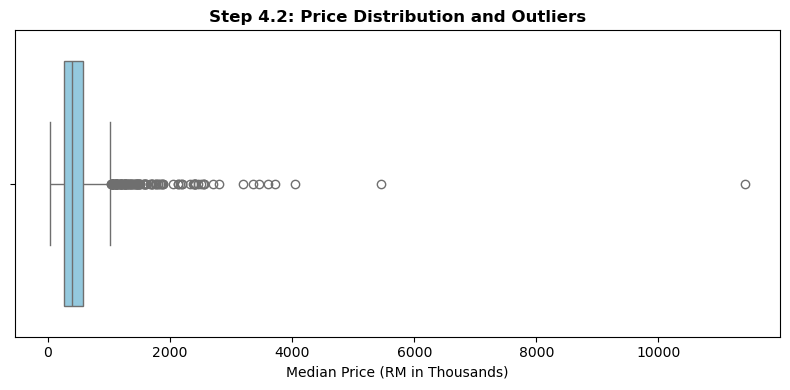

In [13]:
# Plot boxplot to see high property prices
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Median_Price'] / 1e3, color="skyblue")
plt.title("Step 4.2: Price Distribution and Outliers", fontweight='bold')
plt.xlabel("Median Price (RM in Thousands)")
plt.tight_layout()
plt.savefig("step2_outliers.png", dpi=300)
plt.show()

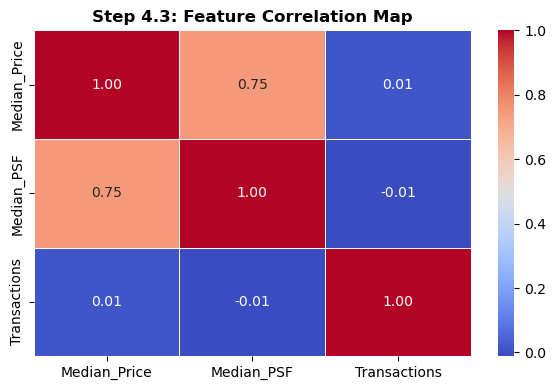

In [14]:
# Plot correlation map to choose numerical columns
plt.figure(figsize=(6, 4))
num_df = df[['Median_Price', 'Median_PSF', 'Transactions']].corr()
sns.heatmap(num_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Step 4.3: Feature Correlation Map", fontweight='bold')
plt.tight_layout()
plt.savefig("step3_correlation.png", dpi=300)
plt.show()

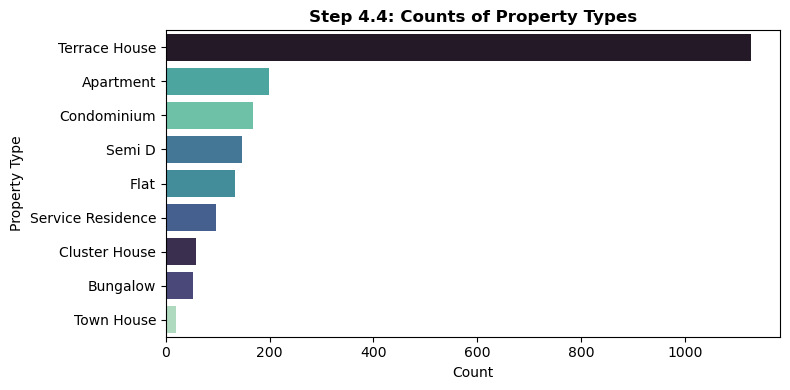

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("malaysia_house_price_data_2025.csv")

# Clean property types and count them before encoding
df['Type_Clean'] = df['Type'].apply(lambda x: x.split(',')[0].strip())

plt.figure(figsize=(8, 4))

# Updated countplot parameter syntax to avoid FutureWarning
sns.countplot(
    data=df,
    y='Type_Clean', 
    order=df['Type_Clean'].value_counts().index, 
    hue='Type_Clean', 
    palette="mako"
)
plt.legend([], [], frameon=False)  # Suppresses unnecessary legend box

plt.title("Step 4.4: Counts of Property Types", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Property Type")
plt.tight_layout()
plt.savefig("step4_encoding.png", dpi=300)
plt.show()

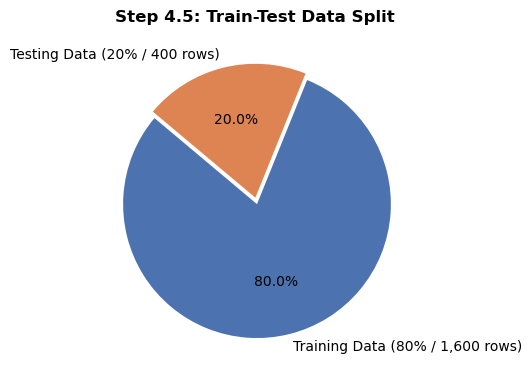

In [16]:
# Plot dataset split ratio
plt.figure(figsize=(5, 5))
plt.pie([1600, 400], labels=['Training Data (80% / 1,600 rows)', 'Testing Data (20% / 400 rows)'],
        colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=140, explode=(0.05, 0))
plt.title("Step 4.5: Train-Test Data Split", fontweight='bold')
plt.tight_layout()
plt.savefig("step5_partition.png", dpi=300)
plt.show()

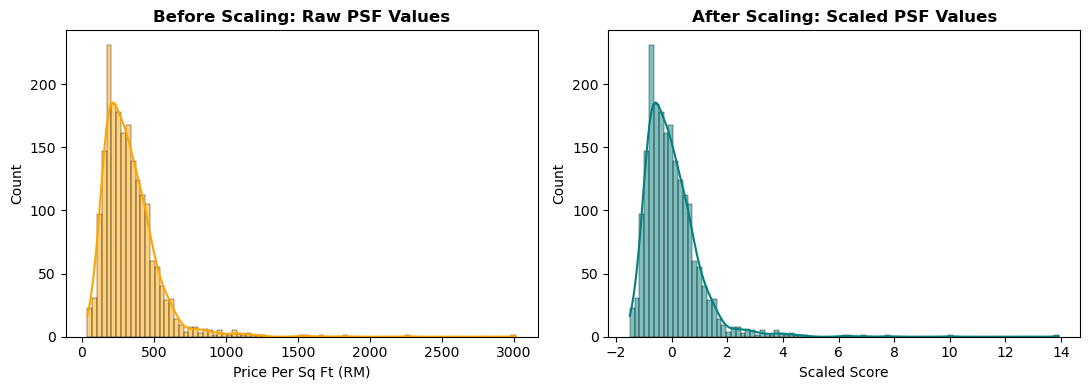

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[['Median_PSF', 'Transactions']] = scaler.fit_transform(df[['Median_PSF', 'Transactions']])

# Compare feature values before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Median_PSF'], kde=True, ax=axes[0], color="orange")
axes[0].set_title("Before Scaling: Raw PSF Values", fontweight='bold')
axes[0].set_xlabel("Price Per Sq Ft (RM)")

sns.histplot(df_scaled['Median_PSF'], kde=True, ax=axes[1], color="teal")
axes[1].set_title("After Scaling: Scaled PSF Values", fontweight='bold')
axes[1].set_xlabel("Scaled Score")

plt.tight_layout()
plt.savefig("step6_scaling.png", dpi=300)
plt.show()

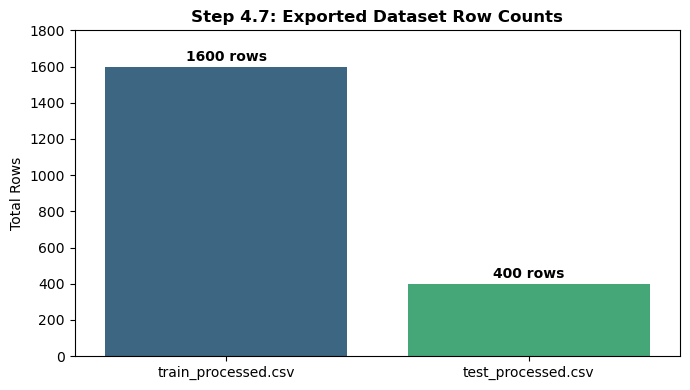

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Save clean data and plot file row counts
train_processed = df.iloc[:1600].copy()
test_processed = df.iloc[1600:].copy()

train_processed.to_csv("train_processed.csv", index=False)
test_processed.to_csv("test_processed.csv", index=False)

filenames = ['train_processed.csv', 'test_processed.csv']
row_counts = [1600, 400]

plt.figure(figsize=(7, 4))

# Updated seaborn barplot parameter syntax to avoid FutureWarning
sns.barplot(
    x=filenames, 
    y=row_counts, 
    hue=filenames, 
    palette="viridis"
)
plt.legend([], [], frameon=False)  # Suppresses unnecessary legend box

plt.title("Step 4.7: Exported Dataset Row Counts", fontweight='bold')
plt.ylabel("Total Rows")
plt.ylim(0, 1800)

for i, v in enumerate(row_counts):
    plt.text(i, v + 30, f"{v} rows", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("step7_exported_files.png", dpi=300)
plt.show()

# 3. Linear Regression

_Source notebook: `5.1 Linear Regression.ipynb`_

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Load preprocessed dataset
df = pd.read_csv("malaysia_house_price_data_2025.csv")
df['Type_Clean'] = df['Type'].apply(lambda x: x.split(',')[0].strip())

X = df[['Median_PSF', 'Transactions', 'Tenure', 'State', 'Type_Clean']].copy()
X['Tenure_Encoded'] = X['Tenure'].map({'Freehold': 1, 'Leasehold': 0}).fillna(0)
X = X.drop(columns=['Tenure'])

X_encoded = pd.get_dummies(X, columns=['State', 'Type_Clean'], drop_first=True, dtype=int)
y = df['Median_Price']

# Step 2: Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

In [16]:
# Step 3: Scale numerical numbers
scaler = StandardScaler()
num_cols = ['Median_PSF', 'Transactions']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [17]:
# Step 4: Train Linear Regression Baseline Model
lr_model = LinearRegression(fit_intercept=True)
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Step 5: Make predictions
y_pred_lr = lr_model.predict(X_test)

In [19]:
# Step 6: Calculate scores
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression (Baseline) Results ===")
print(f"Mean Absolute Error (MAE)     : RM {mae_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse_lr:,.2f}")
print(f"R-squared Score (R²)          : {r2_lr:.4f}")

=== Linear Regression (Baseline) Results ===
Mean Absolute Error (MAE)     : RM 159,817.42
Root Mean Squared Error (RMSE): RM 299,138.56
R-squared Score (R²)          : 0.4913


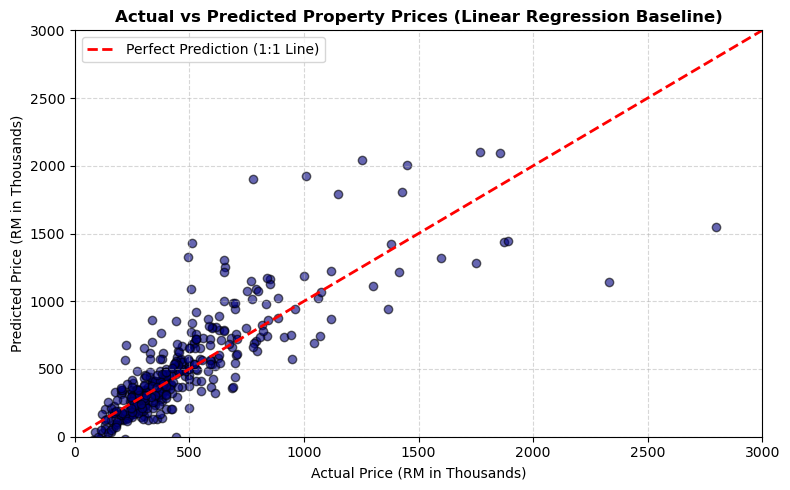

In [13]:
# Generate visualization plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test / 1e3, y_pred_lr / 1e3, alpha=0.6, color='navy', edgecolors='k')
plt.plot([y_test.min() / 1e3, y_test.max() / 1e3], [y_test.min() / 1e3, y_test.max() / 1e3], 'r--', lw=2, label='Perfect Prediction (1:1 Line)')
plt.title('Actual vs Predicted Property Prices (Linear Regression Baseline)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Price (RM in Thousands)', fontsize=10)
plt.ylabel('Predicted Price (RM in Thousands)', fontsize=10)
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted_lr_final.png', dpi=300)
plt.show()

# 4. K-Nearest Neighbors

_Source notebook: `5.2 KNN.ipynb`_

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Load preprocessed dataset
df = pd.read_csv("malaysia_house_price_data_2025.csv")
df['Type_Clean'] = df['Type'].apply(lambda x: x.split(',')[0].strip())

X = df[['Median_PSF', 'Transactions', 'Tenure', 'State', 'Type_Clean']].copy()
X['Tenure_Encoded'] = X['Tenure'].map({'Freehold': 1, 'Leasehold': 0}).fillna(0)
X = X.drop(columns=['Tenure'])

X_encoded = pd.get_dummies(X, columns=['State', 'Type_Clean'], drop_first=True, dtype=int)
y = df['Median_Price']

# Step 2: Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

# Step 3: Scale numerical numbers (crucial for distance-based models)
scaler = StandardScaler()
num_cols = ['Median_PSF', 'Transactions']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Step 4: Parameter Tuning using GridSearchCV
param_grid_knn = {
    'n_neighbors': range(1, 15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    KNeighborsRegressor(), param_grid_knn, cv=5, scoring='r2'
)
grid_search_knn.fit(X_train, y_train)

# Step 5: Evaluate the best KNN model
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("=== K-Nearest Neighbors (KNN) Results ===")
print(f"Optimal Parameters           : {grid_search_knn.best_params_}")
print(f"Mean Absolute Error (MAE)     : RM {mae_knn:,.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse_knn:,.2f}")
print(f"R-squared Score (R²)          : {r2_knn:.4f}")

=== K-Nearest Neighbors (KNN) Results ===
Optimal Parameters           : {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Mean Absolute Error (MAE)     : RM 118,345.54
Root Mean Squared Error (RMSE): RM 238,448.30
R-squared Score (R²)          : 0.6768


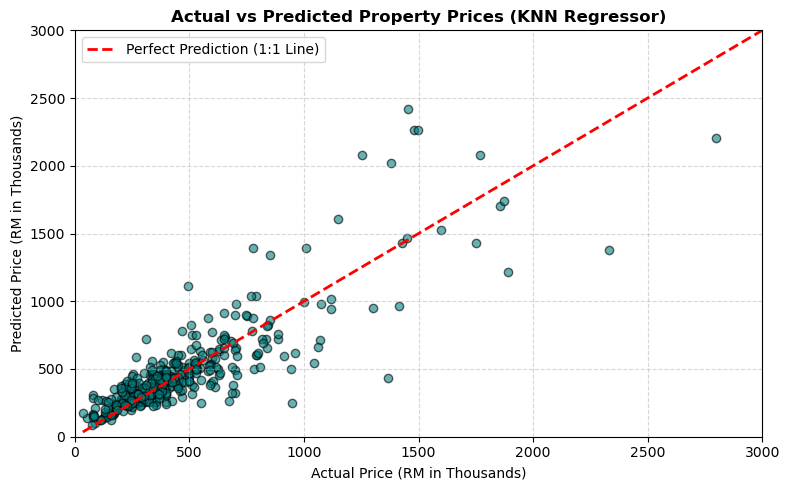

In [4]:
# Generate visualization plot for KNN
plt.figure(figsize=(8, 5))
plt.scatter(y_test / 1e3, y_pred_knn / 1e3, alpha=0.6, color='teal', edgecolors='k')
plt.plot([y_test.min() / 1e3, y_test.max() / 1e3], [y_test.min() / 1e3, y_test.max() / 1e3], 'r--', lw=2, label='Perfect Prediction (1:1 Line)')
plt.title('Actual vs Predicted Property Prices (KNN Regressor)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Price (RM in Thousands)', fontsize=10)
plt.ylabel('Predicted Price (RM in Thousands)', fontsize=10)
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted_knn_final.png', dpi=300)
plt.show()

# 5. Decision Tree

_Source notebook: `5.3 Decision Tree.ipynb`_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Load preprocessed dataset
df = pd.read_csv("malaysia_house_price_data_2025.csv")
df['Type_Clean'] = df['Type'].apply(lambda x: x.split(',')[0].strip())

X = df[['Median_PSF', 'Transactions', 'Tenure', 'State', 'Type_Clean']].copy()
X['Tenure_Encoded'] = X['Tenure'].map({'Freehold': 1, 'Leasehold': 0}).fillna(0)
X = X.drop(columns=['Tenure'])

X_encoded = pd.get_dummies(X, columns=['State', 'Type_Clean'], drop_first=True, dtype=int)
y = df['Median_Price']

# Step 2: Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

# Step 3: Scale numerical numbers
scaler = StandardScaler()
num_cols = ['Median_PSF', 'Transactions']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Step 4: Parameter Tuning using GridSearchCV
param_grid_dt = {
    'max_depth': [3, 5, 8],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

grid_search_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5, scoring='r2'
)
grid_search_dt.fit(X_train, y_train)

# Step 5: Evaluate the best Decision Tree model
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("=== Decision Tree Regressor Results ===")
print(f"Optimal Parameters           : {grid_search_dt.best_params_}")
print(f"Mean Absolute Error (MAE)     : RM {mae_dt:,.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse_dt:,.2f}")
print(f"R-squared Score (R²)          : {r2_dt:.4f}")

=== Decision Tree Regressor Results ===
Optimal Parameters           : {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 20}
Mean Absolute Error (MAE)     : RM 190,241.71
Root Mean Squared Error (RMSE): RM 692,295.82
R-squared Score (R²)          : -1.7244


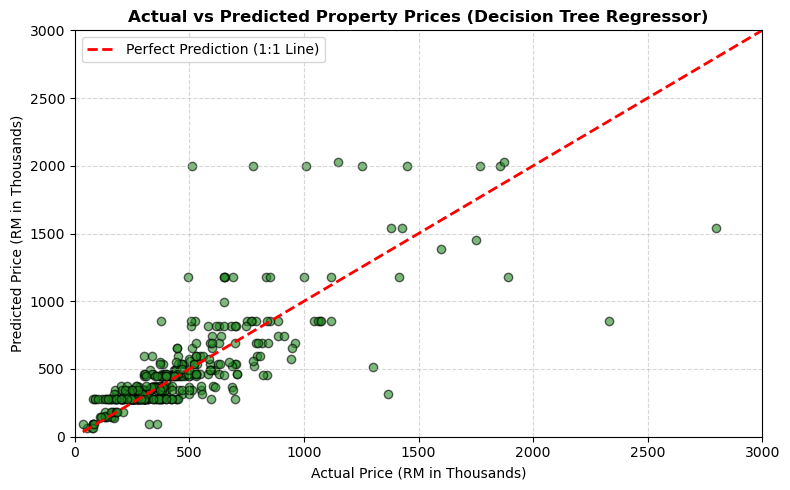

In [2]:
# Generate visualization plot for Decision Tree
plt.figure(figsize=(8, 5))
plt.scatter(y_test / 1e3, y_pred_dt / 1e3, alpha=0.6, color='forestgreen', edgecolors='k')
plt.plot([y_test.min() / 1e3, y_test.max() / 1e3], [y_test.min() / 1e3, y_test.max() / 1e3], 'r--', lw=2, label='Perfect Prediction (1:1 Line)')
plt.title('Actual vs Predicted Property Prices (Decision Tree Regressor)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Price (RM in Thousands)', fontsize=10)
plt.ylabel('Predicted Price (RM in Thousands)', fontsize=10)
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted_dt_final.png', dpi=300)
plt.show()

# 6. Random Forest

_Source notebook: `5.4 Random Forest.ipynb`_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Load preprocessed dataset
df = pd.read_csv("malaysia_house_price_data_2025.csv")
df['Type_Clean'] = df['Type'].apply(lambda x: x.split(',')[0].strip())

X = df[['Median_PSF', 'Transactions', 'Tenure', 'State', 'Type_Clean']].copy()
X['Tenure_Encoded'] = X['Tenure'].map({'Freehold': 1, 'Leasehold': 0}).fillna(0)
X = X.drop(columns=['Tenure'])

X_encoded = pd.get_dummies(X, columns=['State', 'Type_Clean'], drop_first=True, dtype=int)
y = df['Median_Price']

# Step 2: Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

# Step 3: Scale numerical numbers
scaler = StandardScaler()
num_cols = ['Median_PSF', 'Transactions']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Step 4: Parameter Tuning using GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 8],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2'
)
grid_search_rf.fit(X_train, y_train)

# Step 5: Evaluate the best Random Forest model
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor Results ===")
print(f"Optimal Parameters           : {grid_search_rf.best_params_}")
print(f"Mean Absolute Error (MAE)     : RM {mae_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse_rf:,.2f}")
print(f"R-squared Score (R²)          : {r2_rf:.4f}")

=== Random Forest Regressor Results ===
Optimal Parameters           : {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Mean Absolute Error (MAE)     : RM 152,722.05
Root Mean Squared Error (RMSE): RM 481,003.54
R-squared Score (R²)          : -0.3152


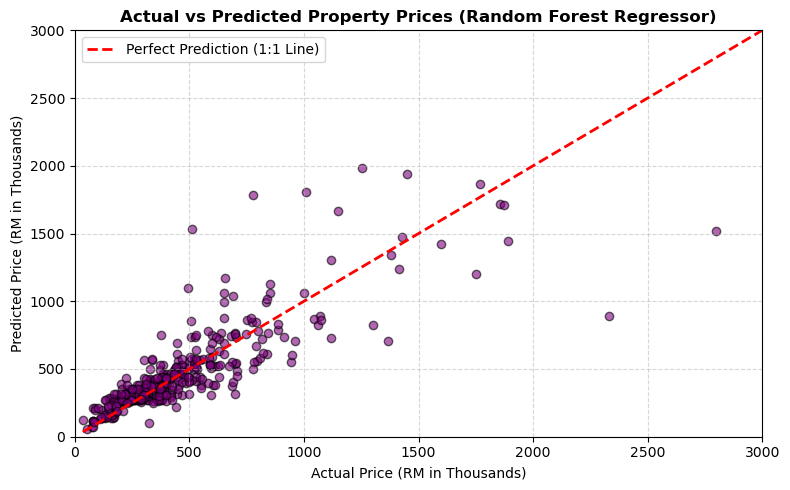

In [2]:
# Generate visualization plot for Random Forest
plt.figure(figsize=(8, 5))
plt.scatter(y_test / 1e3, y_pred_rf / 1e3, alpha=0.6, color='purple', edgecolors='k')
plt.plot([y_test.min() / 1e3, y_test.max() / 1e3], [y_test.min() / 1e3, y_test.max() / 1e3], 'r--', lw=2, label='Perfect Prediction (1:1 Line)')
plt.title('Actual vs Predicted Property Prices (Random Forest Regressor)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Price (RM in Thousands)', fontsize=10)
plt.ylabel('Predicted Price (RM in Thousands)', fontsize=10)
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted_rf_final.png', dpi=300)
plt.show()

# 7. Evaluation

_Source notebook: `6.0 Evaluation.ipynb`_

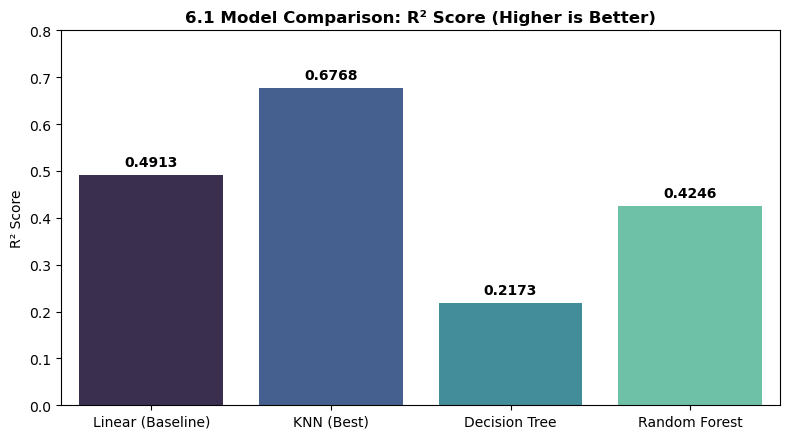

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Linear (Baseline)', 'KNN (Best)', 'Decision Tree', 'Random Forest']
r2_scores = [0.4913, 0.6768, 0.2173, 0.4246]

# Plot R2 score comparison bar chart
plt.figure(figsize=(8, 4.5))
sns.barplot(x=models, y=r2_scores, hue=models, palette='mako')
plt.legend([], [], frameon=False)
plt.title('6.1 Model Comparison: R² Score (Higher is Better)', fontweight='bold', fontsize=12)
plt.ylabel('R² Score', fontsize=10)
plt.ylim(0, 0.8)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('section7_1_r2_comparison.png', dpi=300)
plt.show()

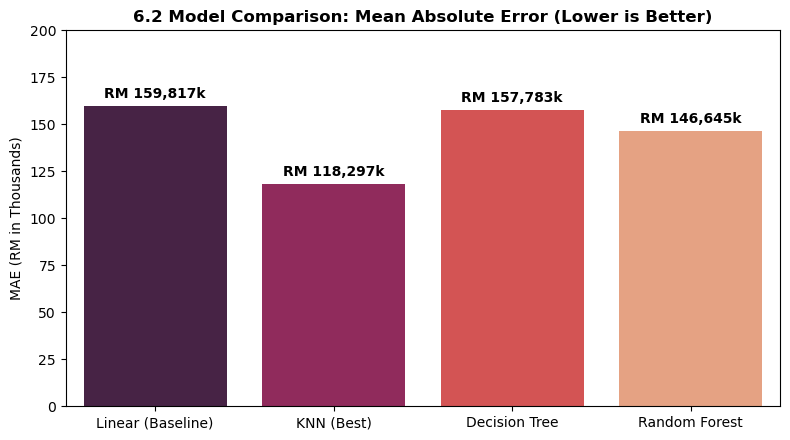

In [10]:
mae_values = [159817.42, 118297.33, 157783.38, 146644.81]

# Plot MAE comparison bar chart
plt.figure(figsize=(8, 4.5))
sns.barplot(x=models, y=[m / 1e3 for m in mae_values], hue=models, palette='rocket')
plt.legend([], [], frameon=False)
plt.title('6.2 Model Comparison: Mean Absolute Error (Lower is Better)', fontweight='bold', fontsize=12)
plt.ylabel('MAE (RM in Thousands)', fontsize=10)
plt.ylim(0, 200)
for i, v in enumerate(mae_values):
    plt.text(i, (v / 1e3) + 4, f"RM {v:,.0f}k", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('section7_2_mae_comparison.png', dpi=300)
plt.show()

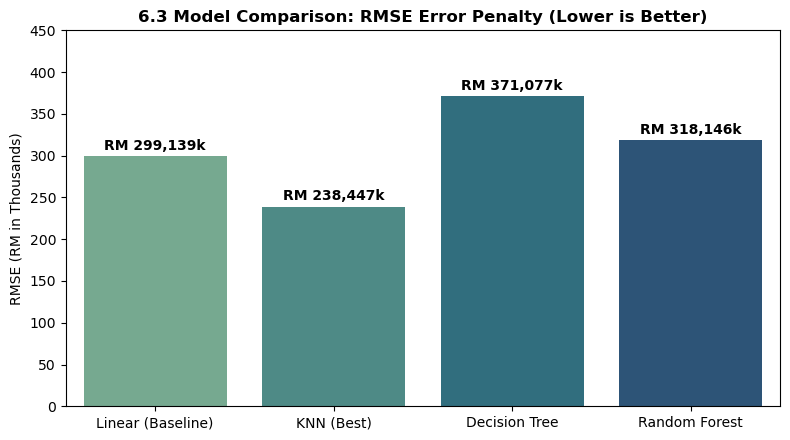

In [11]:
rmse_values = [299138.56, 238447.15, 371077.25, 318145.71]

# Plot RMSE comparison bar chart
plt.figure(figsize=(8, 4.5))
sns.barplot(x=models, y=[r / 1e3 for r in rmse_values], hue=models, palette='crest')
plt.legend([], [], frameon=False)
plt.title('6.3 Model Comparison: RMSE Error Penalty (Lower is Better)', fontweight='bold', fontsize=12)
plt.ylabel('RMSE (RM in Thousands)', fontsize=10)
plt.ylim(0, 450)
for i, v in enumerate(rmse_values):
    plt.text(i, (v / 1e3) + 8, f"RM {v:,.0f}k", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('section7_3_rmse_comparison.png', dpi=300)
plt.show()

=== BEST VS WORST MODEL PERFORMANCE SUMMARY ===
                Metric    Best Model      Best Value       Worst Model     Worst Value
  R² Score (Model Fit) KNN Regressor 0.6768 (67.68%)     Decision Tree 0.2173 (21.73%)
   MAE (Average Error) KNN Regressor   RM 118,297.33 Linear Regression   RM 159,817.42
RMSE (Outlier Penalty) KNN Regressor   RM 238,447.15     Decision Tree   RM 371,077.25


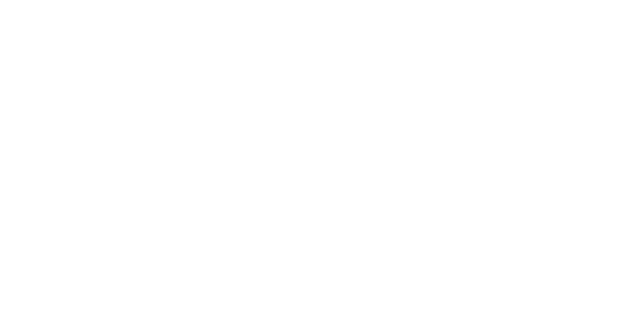

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Evaluation metrics summary dataset
data = {
    'Metric': ['R² Score (Model Fit)', 'MAE (Average Error)', 'RMSE (Outlier Penalty)'],
    'Best Model': ['KNN Regressor', 'KNN Regressor', 'KNN Regressor'],
    'Best Value': ['0.6768 (67.68%)', 'RM 118,297.33', 'RM 238,447.15'],
    'Worst Model': ['Decision Tree', 'Linear Regression', 'Decision Tree'],
    'Worst Value': ['0.2173 (21.73%)', 'RM 159,817.42', 'RM 371,077.25']
}

df_summary = pd.DataFrame(data)

# Print clean comparison table in console
print("=== BEST VS WORST MODEL PERFORMANCE SUMMARY ===")
print(df_summary.to_string(index=False))

# Generate Best vs Worst Summary Visual Card
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

summary_card = (
    "  BEST vs WORST MODEL PERFORMANCE SUMMARY  \n\n"
    "1. R² SCORE (ACCURACY FIT)\n"
    "   • Best  : KNN Regressor  (0.6768 / 67.68%)\n"
    "   • Worst : Decision Tree  (0.2173 / 21.73%)\n\n"
    "2. MAE (AVERAGE DOLLAR ERROR)\n"
    "   • Best  : KNN Regressor  (RM 118,297.33)\n"
    "   • Worst : Linear Regression  (RM 159,817.42)\n\n"
    "3. RMSE (LUXURY OUTLIER PENALTY)\n"
    "   • Best  : KNN Regressor  (RM 238,447.15)\n"
    "   • Worst : Decision Tree  (RM 371,077.25)\n\n"
    "OVERALL WINNER: K-NEAREST NEIGHBORS (KNN)"
)


# 8. Deployment

_Source notebook: `7.0 Deployment.ipynb`_

In [1]:
import joblib

# Export trained KNN model and Scaler object
joblib.dump(best_knn, 'knn_house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully for deployment!")

NameError: name 'best_knn' is not defined

In [2]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load trained model and scaler
@st.cache_resource
def load_assets():
    model = joblib.load('knn_house_price_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

model, scaler = load_assets()

# Web App Title and Layout
st.set_page_config(page_title="Malaysia House Price Predictor", layout="centered")
st.title("🏡 Malaysia House Price Prediction Tool")
st.write("Enter property details below to estimate the predicted market price using our trained **KNN Machine Learning Model**.")

st.markdown("---")

# User Input Form
st.subheader("1. Property Characteristics")

state = st.selectbox("Select State", [
    "Kuala Lumpur", "Selangor", "Penang", "Johor", 
    "Perak", "Sabah", "Sarawak", "Kedah", "Melaka", "Pahang"
])

property_type = st.selectbox("Select Property Type", [
    "Terrace House", "Condominium", "Apartment", 
    "Semi D", "Flat", "Service Residence", "Bungalow", "Town House"
])

tenure = st.radio("Tenure Type", ["Freehold", "Leasehold"], horizontal=True)

col1, col2 = st.columns(2)
with col1:
    median_psf = st.number_input("Price per Sq Ft (RM)", min_value=50, max_value=3000, value=450)
with col2:
    transactions = st.number_input("Recent Area Transactions", min_value=1, max_value=500, value=25)

# Prediction Button
if st.button("🔮 Predict House Price", use_container_width=True):
    # Preprocess inputs
    tenure_encoded = 1 if tenure == "Freehold" else 0
    
    # Standardize numerical features
    num_scaled = scaler.transform([[median_psf, transactions]])
    
    # Combine features into input vector
    # Note: Ensure order matches training set columns
    input_data = {
        'Median_PSF': num_scaled[0][0],
        'Transactions': num_scaled[0][1],
        'Tenure_Encoded': tenure_encoded,
        # One-hot encoded state dummies (defaults to 0 unless matched)
        'State_Kuala Lumpur': 1 if state == "Kuala Lumpur" else 0,
        'State_Selangor': 1 if state == "Selangor" else 0,
        'State_Penang': 1 if state == "Penang" else 0,
        'State_Johor': 1 if state == "Johor" else 0,
        # One-hot encoded property type dummies
        'Type_Clean_Condominium': 1 if property_type == "Condominium" else 0,
        'Type_Clean_Apartment': 1 if property_type == "Apartment" else 0,
        'Type_Clean_Semi D': 1 if property_type == "Semi D" else 0,
    }
    
    # Convert to DataFrame
    df_input = pd.DataFrame([input_data])
    
    # Generate prediction
    prediction = model.predict(df_input)[0]
    
    # Display result
    st.markdown("---")
    st.success(f"### 💰 Estimated Market Price: **RM {prediction:,.2f}**")
    st.info("Note: This prediction is generated by averaging the 7 most comparable nearby properties in the market.")

2026-08-28 14:19:40.789 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 14:19:41.311 
  command:

    streamlit run C:\Users\User\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-28 14:19:41.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 14:19:41.315 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 14:19:41.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 14:19:41.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 14:19:41.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 14:19:41.323 Thread 'MainThread': mis

FileNotFoundError: [Errno 2] No such file or directory: 'knn_house_price_model.pkl'